# Phase 1: Data Loading & Exploratory Data Analysis (EDA)

Project : MBTI Personality Type Prediction from Text
Dataset : https://www.kaggle.com/datasets/datasnaek/mbti-type
Author  : PRML Project

Dataset quirk:
Each row contains 50 of a user's recent forum posts, concatenated into a
single string and separated by '|||' (three pipe characters).

This script performs:
1. Loading the raw CSV and initial inspection
2. Missing-value and duplicate checks
3. Distribution of the 16 MBTI classes  (expect heavy imbalance)
4. Word-count distribution per user


In [1]:
%matplotlib inline

In [2]:
# -- Imports ------------------------------------------------------------------
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

# -- Configuration ------------------------------------------------------------
# Aesthetic defaults for all plots
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.15)
plt.rcParams.update({
    "figure.figsize": (14, 6),
    "axes.titleweight": "bold",
    "axes.titlesize": 15,
    "axes.labelsize": 12,
})

# Path to the raw dataset  (update if your file is elsewhere)
DATA_PATH = os.path.join(os.getcwd(), "mbti_1.csv")

## 1. LOAD THE DATASET


In [3]:
def load_data(path: str = DATA_PATH) -> pd.DataFrame:
    """
    Load the MBTI dataset from CSV.

    Parameters
    ----------
    path : str
        File path to the CSV.

    Returns
    -------
    pd.DataFrame
        Raw dataframe with columns ['type', 'posts'].
    """
    df = pd.read_csv(path)
    print("=" * 60)
    print("  DATASET LOADED SUCCESSFULLY")
    print("=" * 60)
    print(f"  Shape        : {df.shape[0]} rows  x  {df.shape[1]} columns")
    print(f"  Columns      : {list(df.columns)}")
    print(f"  Memory usage : {df.memory_usage(deep=True).sum() / 1e6:.2f} MB")
    print("=" * 60)
    return df

## 2. DATA QUALITY CHECKS


In [4]:
def check_data_quality(df: pd.DataFrame) -> None:
    """
    Print missing-value counts and duplicate-row counts.

    Insights to watch for:
        - If any posts cells are NaN, those rows should be dropped or filled.
        - Duplicates can skew the class distribution even further.
    """
    print("\n" + "-" * 60)
    print("  DATA QUALITY CHECKS")
    print("-" * 60)

    # -- Missing values ---------------------------------------------------
    missing = df.isnull().sum()
    print("\n  Missing values per column:")
    for col, count in missing.items():
        status = "OK (None)" if count == 0 else f"WARNING: {count}"
        print(f"    {col:>10s} : {status}")

    # -- Duplicates -------------------------------------------------------
    n_dup = df.duplicated().sum()
    print(f"\n  Duplicate rows : {n_dup}")

    if n_dup > 0:
        print("  -> Recommendation: Investigate and drop exact duplicates.")
    else:
        print("  -> No duplicates found -- data is clean on this front.")

    # -- Quick dtype overview ----------------------------------------------
    print("\n  Data types:")
    for col in df.columns:
        print(f"    {col:>10s} : {df[col].dtype}")

    # -- First few rows (truncated posts for readability) ------------------
    print("\n  First 3 rows (posts truncated to 120 chars):")
    preview = df.head(3).copy()
    preview["posts"] = preview["posts"].str[:120] + " ..."
    print(preview.to_string(index=False))
    print("-" * 60)

## 3. MBTI CLASS DISTRIBUTION


In [5]:
def plot_class_distribution(df: pd.DataFrame) -> None:
    """
    Bar chart of the 16 MBTI types sorted by frequency.

    KEY INSIGHT TO WATCH FOR:
        The dataset is sourced from the PersonalityCafe forum, which attracts
        a disproportionately large number of Introverted-iNtuitive (IN--)
        types.  Expect INFP, INFJ, INTP, INTJ to dominate.  This class
        imbalance will heavily influence model training and must be addressed
        in later phases (e.g., SMOTE, class weights, stratified splits).
    """
    fig, axes = plt.subplots(1, 2, figsize=(18, 6))

    # -- 3a. Absolute counts -----------------------------------------------
    type_counts = df["type"].value_counts().sort_values(ascending=False)

    colors = sns.color_palette("viridis", n_colors=16)

    ax1 = axes[0]
    bars = ax1.bar(type_counts.index, type_counts.values, color=colors, edgecolor="white")
    ax1.set_title("MBTI Type Distribution (Absolute Counts)")
    ax1.set_xlabel("MBTI Type")
    ax1.set_ylabel("Number of Users")
    ax1.tick_params(axis="x", rotation=45)

    # Annotate each bar with its count
    for bar, count in zip(bars, type_counts.values):
        ax1.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 20,
            f"{count}",
            ha="center", va="bottom", fontsize=9, fontweight="bold"
        )

    # -- 3b. Percentage share -----------------------------------------------
    ax2 = axes[1]
    type_pct = (type_counts / type_counts.sum()) * 100

    ax2.barh(type_pct.index[::-1], type_pct.values[::-1], color=colors[::-1], edgecolor="white")
    ax2.set_title("MBTI Type Distribution (Percentage Share)")
    ax2.set_xlabel("Percentage of Dataset (%)")
    ax2.set_ylabel("MBTI Type")

    # Annotate with percentage
    for i, (pct, mbti) in enumerate(zip(type_pct.values[::-1], type_pct.index[::-1])):
        ax2.text(pct + 0.3, i, f"{pct:.1f}%", va="center", fontsize=9)

    plt.tight_layout()
    plt.savefig("eda_class_distribution.png", dpi=150, bbox_inches="tight")
    plt.show()

    # -- Summary statistics -------------------------------------------------
    print("\n  CLASS IMBALANCE SUMMARY")
    print("  " + "-" * 40)
    print(f"  Most common   : {type_counts.index[0]}  ({type_counts.iloc[0]} users, {type_pct.iloc[0]:.1f}%)")
    print(f"  Least common  : {type_counts.index[-1]}  ({type_counts.iloc[-1]} users, {type_pct.iloc[-1]:.1f}%)")
    print(f"  Imbalance ratio (max/min) : {type_counts.iloc[0] / type_counts.iloc[-1]:.1f}x")
    print("  " + "-" * 40)

## 4. WORD COUNT DISTRIBUTION PER USER


In [6]:
def add_word_count(df: pd.DataFrame) -> pd.DataFrame:
    """
    Add a 'word_count' column = total words across all 50 posts per user.

    We split on whitespace here (a rough but fast proxy); more sophisticated
    tokenisation will happen in Phase 2 (preprocessing).
    """
    df = df.copy()
    df["word_count"] = df["posts"].apply(lambda x: len(x.split()))
    return df


def plot_word_count_distribution(df: pd.DataFrame) -> None:
    """
    Histogram + box plot of word counts per user.

    KEY INSIGHTS TO WATCH FOR:
        - Are there outliers with extremely long or extremely short posts?
        - Does word count vary across personality types?  (e.g., Extroverts
          might write more.)  We'll test that hypothesis visually.
    """
    fig, axes = plt.subplots(1, 3, figsize=(20, 6))

    # -- 4a. Histogram of word counts ----------------------------------------
    ax1 = axes[0]
    ax1.hist(df["word_count"], bins=50, color="#4C72B0", edgecolor="white", alpha=0.85)
    ax1.axvline(df["word_count"].mean(), color="red", linestyle="--", linewidth=1.5, label=f"Mean = {df['word_count'].mean():.0f}")
    ax1.axvline(df["word_count"].median(), color="orange", linestyle="--", linewidth=1.5, label=f"Median = {df['word_count'].median():.0f}")
    ax1.set_title("Distribution of Word Counts per User")
    ax1.set_xlabel("Total Word Count (across 50 posts)")
    ax1.set_ylabel("Number of Users")
    ax1.legend(fontsize=10)

    # -- 4b. Box plot of word counts ----------------------------------------
    ax2 = axes[1]
    sns.boxplot(y=df["word_count"], ax=ax2, color="#55A868", width=0.4)
    ax2.set_title("Word Count Box Plot")
    ax2.set_ylabel("Total Word Count")

    # -- 4c. Word count by MBTI type ----------------------------------------
    # Sort types by median word count for a more informative view
    type_order = df.groupby("type")["word_count"].median().sort_values(ascending=False).index
    ax3 = axes[2]
    sns.boxplot(
        data=df, x="type", y="word_count",
        order=type_order, ax=ax3,
        palette="Set2", fliersize=2,
    )
    ax3.set_title("Word Count by MBTI Type")
    ax3.set_xlabel("MBTI Type")
    ax3.set_ylabel("Total Word Count")
    ax3.tick_params(axis="x", rotation=45)

    plt.tight_layout()
    plt.savefig("eda_word_count_distribution.png", dpi=150, bbox_inches="tight")
    plt.show()

    # -- Summary statistics -------------------------------------------------
    print("\n  WORD COUNT SUMMARY")
    print("  " + "-" * 40)
    print(f"  Mean   : {df['word_count'].mean():.0f} words")
    print(f"  Median : {df['word_count'].median():.0f} words")
    print(f"  Std    : {df['word_count'].std():.0f} words")
    print(f"  Min    : {df['word_count'].min()} words")
    print(f"  Max    : {df['word_count'].max()} words")
    print("  " + "-" * 40)

## 5. BONUS -- INDIVIDUAL DIMENSION ANALYSIS


In [7]:
def plot_dimension_distribution(df: pd.DataFrame) -> None:
    """
    Break each MBTI type into its 4 binary axes and plot the balance of each:
        E vs I  |  S vs N  |  T vs F  |  J vs P

    This tells us which specific dimensions are most / least balanced in the
    dataset and can guide us toward a multi-label (4 binary classifiers)
    approach.
    """
    df = df.copy()

    # Extract each of the 4 preference dimensions
    df["E_I"] = df["type"].str[0]   # Extraversion / Introversion
    df["S_N"] = df["type"].str[1]   # Sensing / iNtuition
    df["T_F"] = df["type"].str[2]   # Thinking / Feeling
    df["J_P"] = df["type"].str[3]   # Judging / Perceiving

    dims = {
        "E vs I (Extraversion / Introversion)": "E_I",
        "S vs N (Sensing / iNtuition)":          "S_N",
        "T vs F (Thinking / Feeling)":           "T_F",
        "J vs P (Judging / Perceiving)":         "J_P",
    }

    fig, axes = plt.subplots(1, 4, figsize=(20, 5))

    for ax, (title, col) in zip(axes, dims.items()):
        counts = df[col].value_counts()

        # Use contrasting colour pairs for each axis
        color_map = {
            "E_I": ["#FF6B6B", "#4ECDC4"],
            "S_N": ["#FFE66D", "#1A535C"],
            "T_F": ["#F38181", "#3AAFB9"],
            "J_P": ["#FCB69F", "#667EEA"],
        }
        colors = color_map[col]

        wedges, texts, autotexts = ax.pie(
            counts.values,
            labels=counts.index,
            autopct="%1.1f%%",
            colors=colors,
            startangle=90,
            textprops={"fontsize": 12, "fontweight": "bold"},
        )
        ax.set_title(title, fontsize=11, fontweight="bold")

    plt.suptitle("Distribution of Each MBTI Dimension", fontsize=15, fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.savefig("eda_dimension_distribution.png", dpi=150, bbox_inches="tight")
    plt.show()

    # Print imbalance for each dimension
    print("\n  DIMENSION-LEVEL IMBALANCE")
    print("  " + "-" * 50)
    for title, col in dims.items():
        counts = df[col].value_counts()
        majority = counts.index[0]
        majority_pct = counts.iloc[0] / counts.sum() * 100
        print(f"  {title:>45s} ->  {majority} dominates at {majority_pct:.1f}%")
    print("  " + "-" * 50)

## MAIN -- RUN ALL PHASES


In [8]:
def main():
    """Execute the full Phase 1 EDA pipeline."""

    # Step 1: Load
    df = load_data()

    # Step 2: Quality checks
    check_data_quality(df)

    # Step 3: Class distribution
    plot_class_distribution(df)

    # Step 4: Word counts
    df = add_word_count(df)
    plot_word_count_distribution(df)

    # Step 5 (Bonus): Dimension-level analysis
    plot_dimension_distribution(df)

    print("\n[DONE]  Phase 1 EDA complete.  Charts saved to working directory.")
    print("    Next -> Phase 2: Text Preprocessing & Feature Engineering\n")

    return df

## Run Phase 1


  DATASET LOADED SUCCESSFULLY
  Shape        : 8675 rows  x  2 columns
  Columns      : ['type', 'posts']
  Memory usage : 73.32 MB

------------------------------------------------------------
  DATA QUALITY CHECKS
------------------------------------------------------------

  Missing values per column:
          type : OK (None)
         posts : OK (None)

  Duplicate rows : 0
  -> No duplicates found -- data is clean on this front.

  Data types:
          type : str
         posts : str

  First 3 rows (posts truncated to 120 chars):
type                                                                                                                        posts
INFJ 'http://www.youtube.com/watch?v=qsXHcwe3krw|||http://41.media.tumblr.com/tumblr_lfouy03PMA1qa1rooo1_500.jpg|||enfp and i ...
ENTP 'I'm finding the lack of me in these posts very alarming.|||Sex can be boring if it's in the same position often. For ex ...
INTP 'Good one  _____   https://www.youtube.com/watch?v=fHiGbolFF

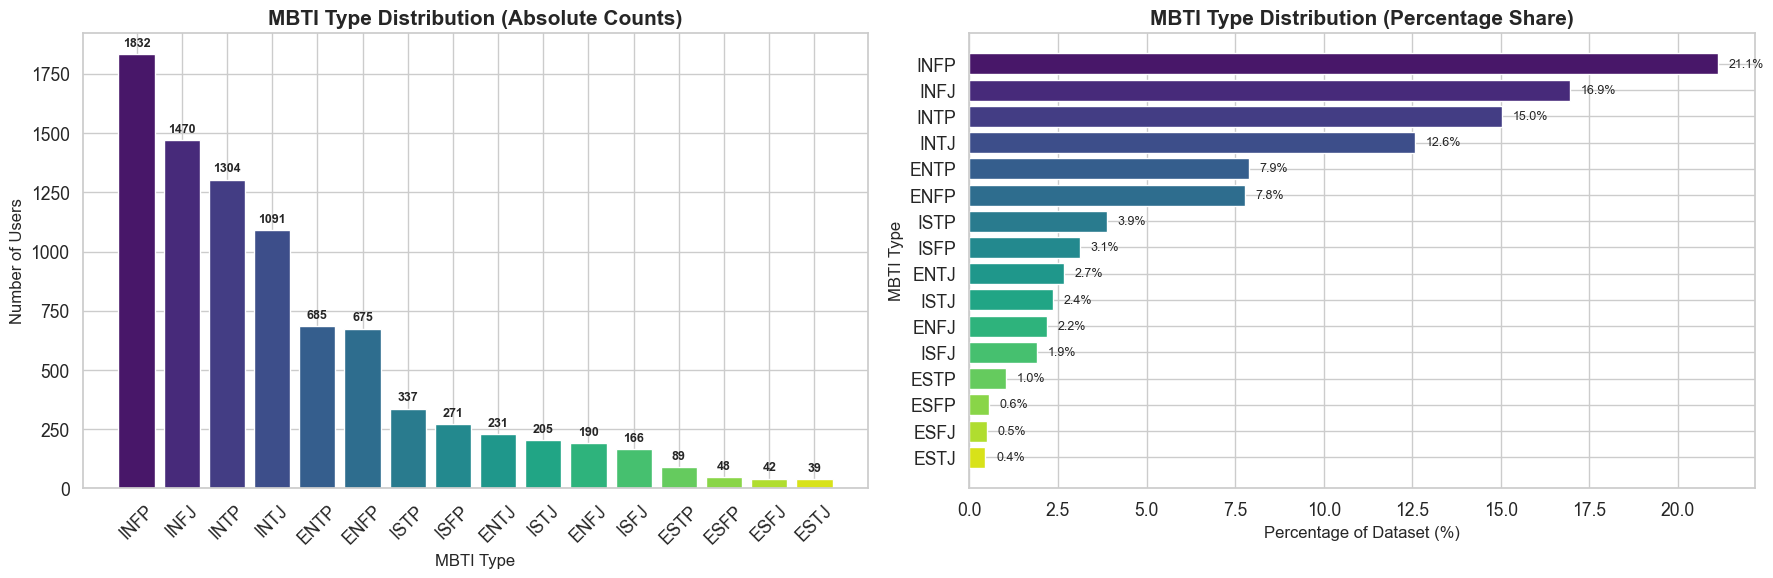


  CLASS IMBALANCE SUMMARY
  ----------------------------------------
  Most common   : INFP  (1832 users, 21.1%)
  Least common  : ESTJ  (39 users, 0.4%)
  Imbalance ratio (max/min) : 47.0x
  ----------------------------------------


C:\Users\rudra\AppData\Local\Temp\ipykernel_7788\202502801.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


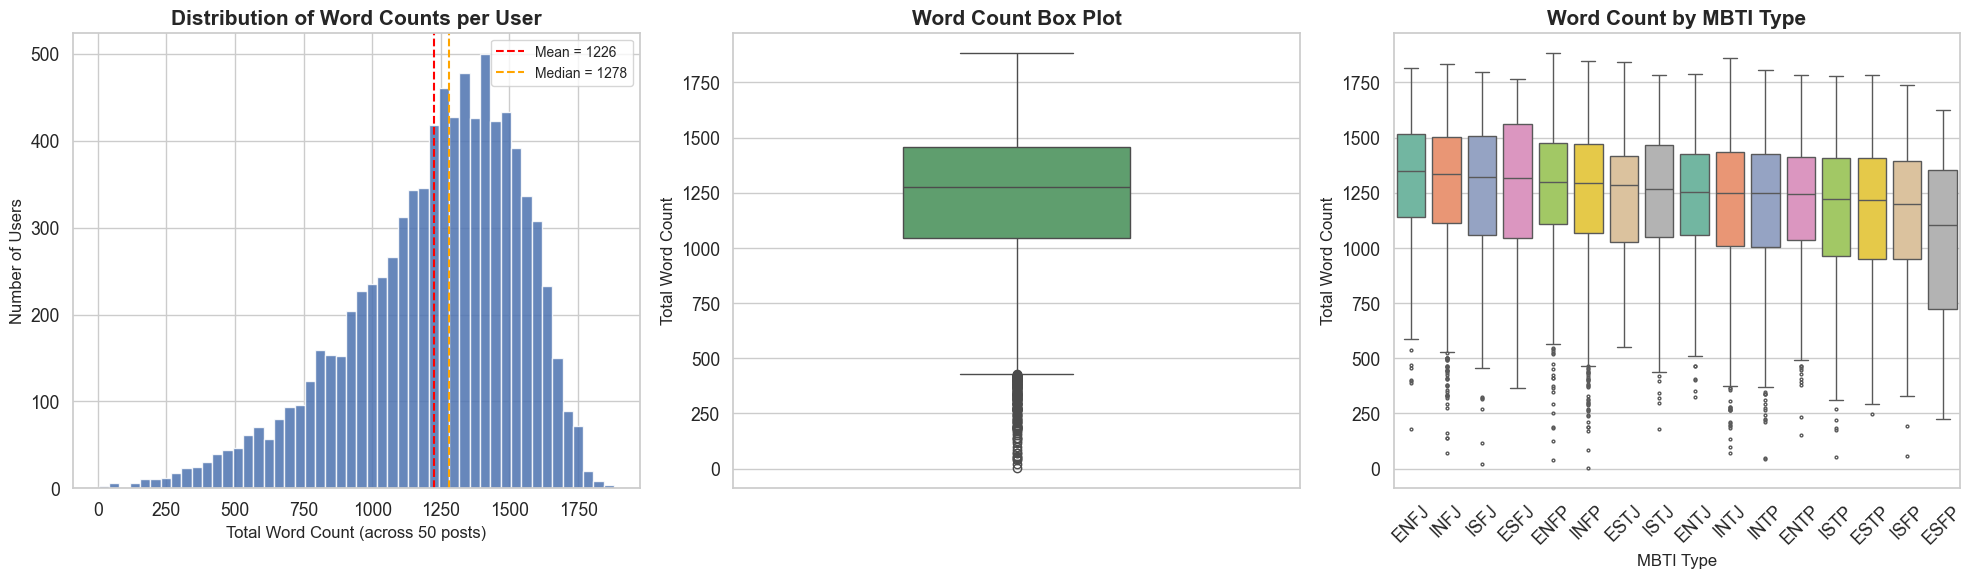


  WORD COUNT SUMMARY
  ----------------------------------------
  Mean   : 1226 words
  Median : 1278 words
  Std    : 311 words
  Min    : 4 words
  Max    : 1881 words
  ----------------------------------------


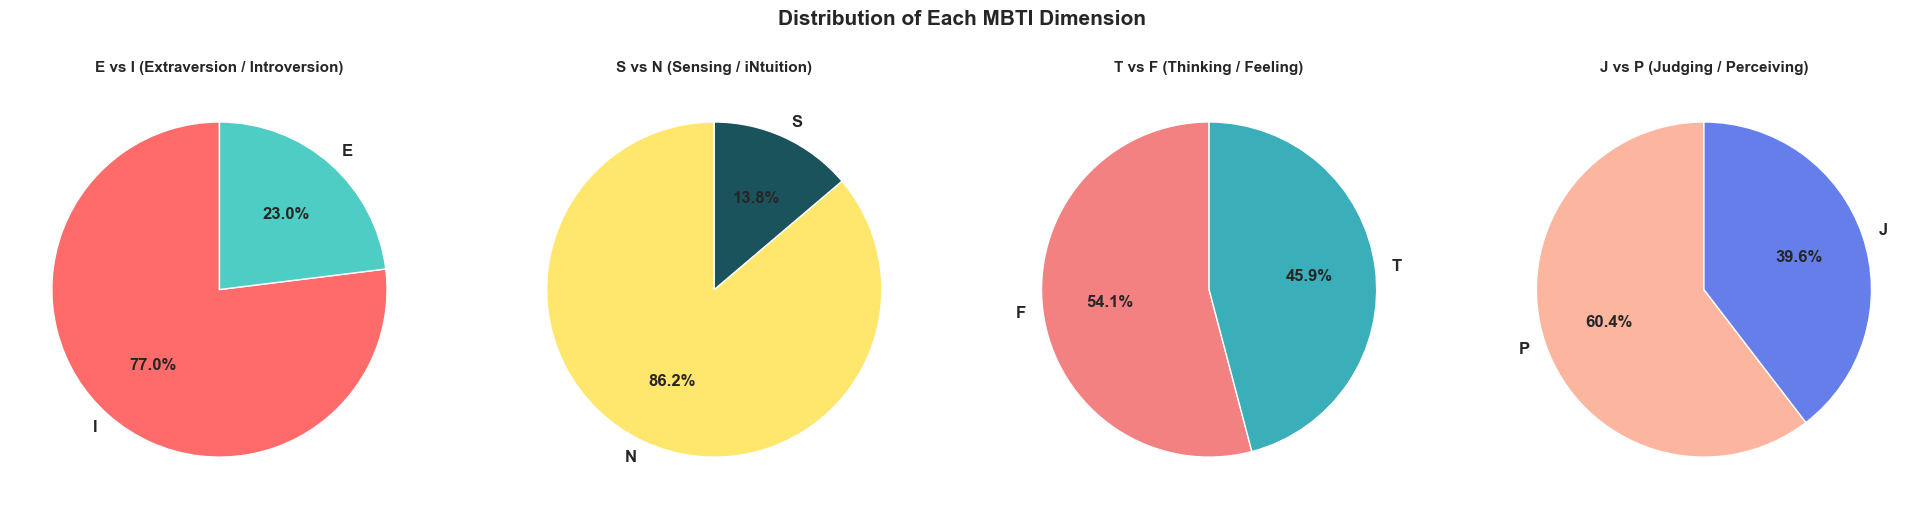


  DIMENSION-LEVEL IMBALANCE
  --------------------------------------------------
           E vs I (Extraversion / Introversion) ->  I dominates at 77.0%
                   S vs N (Sensing / iNtuition) ->  N dominates at 86.2%
                    T vs F (Thinking / Feeling) ->  F dominates at 54.1%
                  J vs P (Judging / Perceiving) ->  P dominates at 60.4%
  --------------------------------------------------

[DONE]  Phase 1 EDA complete.  Charts saved to working directory.
    Next -> Phase 2: Text Preprocessing & Feature Engineering



In [9]:
df = main()